In [1]:
#1

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def implicit_euler_solve(lam, u0, T, dt):
    """Решает du/dt = lambda * u с u(0) = u0, неявным методом Эйлера"""
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty(num_steps + 1)
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] / (1 - dt * lam)
    return tt, y

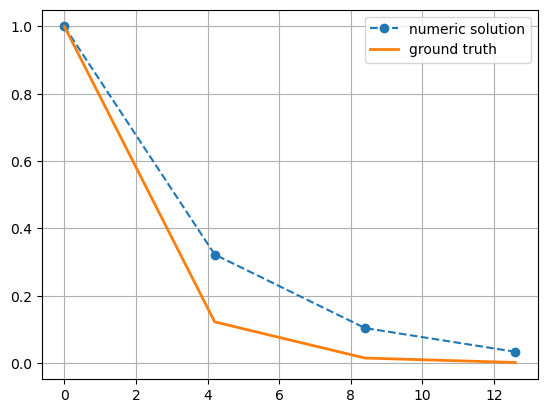

In [3]:
# Нарисовать графики с разными значениями шага, и отдельно при lambda*tau > 2.
 
lam = -0.5
tt, y = implicit_euler_solve(lam, u0=1.0, T=8/abs(lam), dt=2.1/abs(lam))
plt.plot(tt, y, 'o--', label='numeric solution')
plt.plot(tt, np.exp(lam*tt), '-', lw=2, label='ground truth')
plt.legend(loc='best')
plt.grid(True)

In [4]:
# Для тестирования

lam = -0.5 
tt, y = implicit_euler_solve(lam, u0=1.0, T=8/abs(lam), dt=2.1/abs(lam))

assert (y > 0).all()

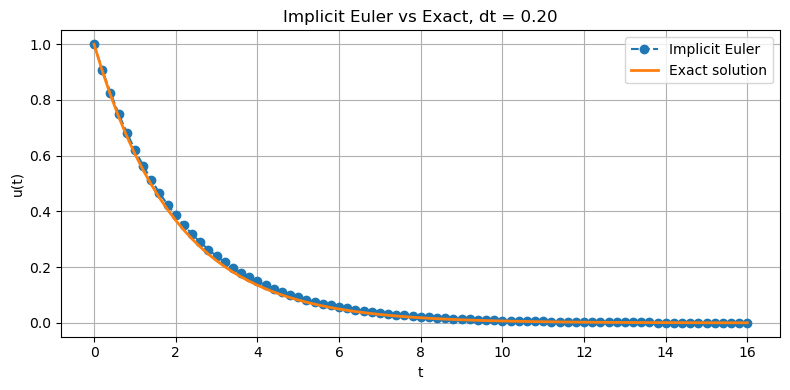

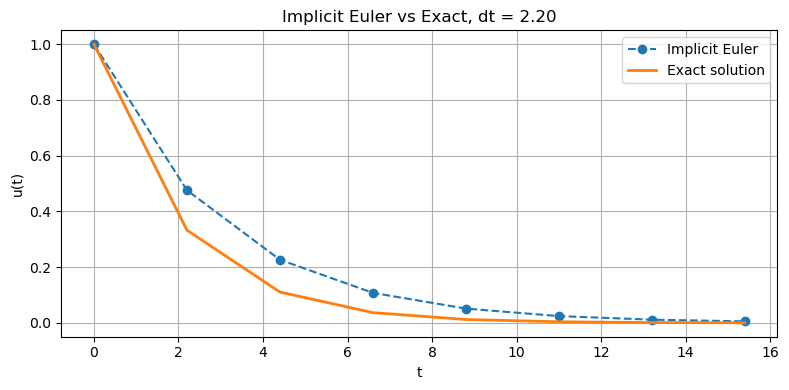

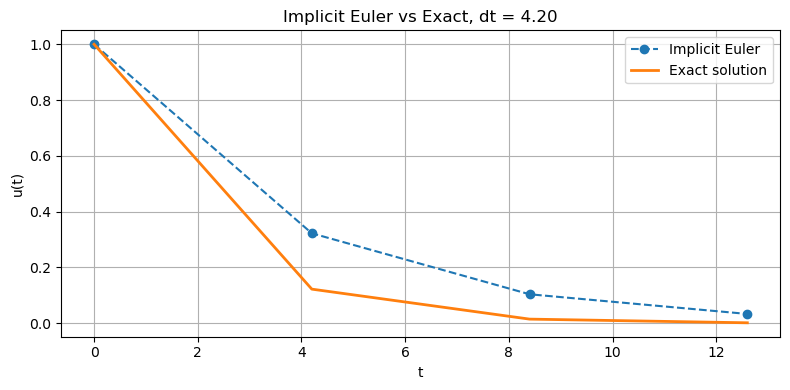

In [5]:
lam = -0.5
u0 = 1.0
T = 8 / abs(lam)
dt_values = [0.1 / abs(lam), 1.1 / abs(lam), 2.1 / abs(lam)]

for dt in dt_values:
    tt, y = implicit_euler_solve(lam, u0=u0, T=T, dt=dt)
    y_exact = np.exp(lam * tt)

    plt.figure(figsize=(8, 4))
    plt.plot(tt, y, 'o--', label='Implicit Euler')
    plt.plot(tt, y_exact, '-', lw=2, label='Exact solution')
    plt.title(f"Implicit Euler vs Exact, dt = {dt:.2f}")
    plt.xlabel("t")
    plt.ylabel("u(t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
#2

In [7]:
def euler_solve2(a, u0, T, dt):
    """Явная схема Эйлера для системы du/dt = A u"""
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty((num_steps + 1, len(u0)))
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt * a @ y[k]
    return tt, y


In [8]:
from scipy.linalg import expm

def mat_exp_solve(a, u0, tt):
    """Точное решение через expm(t*A) * u0"""
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    y = np.empty((len(tt), len(u0)))
    for i, t in enumerate(tt):
        y[i] = expm(t * a) @ u0
    return y


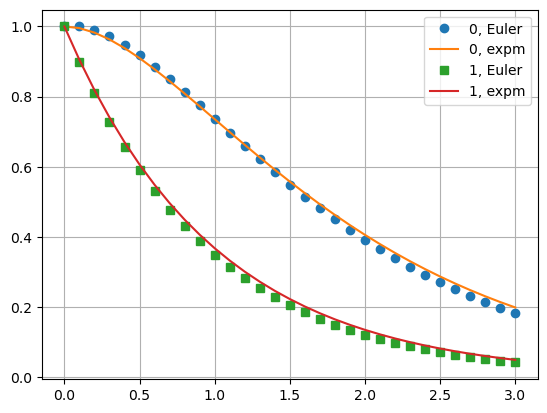

In [9]:
# Solve via Euler's method, compare to the matrix exponential

from scipy.linalg import expm

a = np.array([[-1, 1],
              [0, -1]], dtype=float)
t, y  = euler_solve2(a, u0=[1, 1], T=3, dt=0.1)
ym = mat_exp_solve(a, [1, 1], t)

plt.plot(t, y[:, 0], 'o', label='0, Euler')
plt.plot(t, ym[:, 0], '-', label='0, expm')

plt.plot(t, y[:, 1], 's', label='1, Euler')
plt.plot(t, ym[:, 1], '-', label='1, expm')

plt.legend(loc='best')
plt.grid(True)

In [10]:
#3

In [11]:
import numpy as np

A = np.array([
    [-800, 0.04, 0.02],
    [0,   -5,   -3],
    [0,    1,   -1]
], dtype=float)

eigvals = np.linalg.eigvals(A)
print("Собственные значения A:", eigvals)

# Число жесткости = max |Re(λ)| / min |Re(λ)| (Re(λ) < 0)
reals = -np.real(eigvals)
stiffness = reals.max() / reals[reals > 0].min()
print(f"Число жёсткости: {stiffness:.2f}")


Собственные значения A: [-800.   -4.   -2.]
Число жёсткости: 400.00


In [12]:
def implicit_euler_system(A, u0, T, dt):
    A = np.asarray(A, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty((num_steps + 1, len(u0)))
    y[0] = u0
    I = np.eye(A.shape[0])
    for k in range(num_steps):
        y[k+1] = np.linalg.solve(I - dt * A, y[k])
    return tt, y


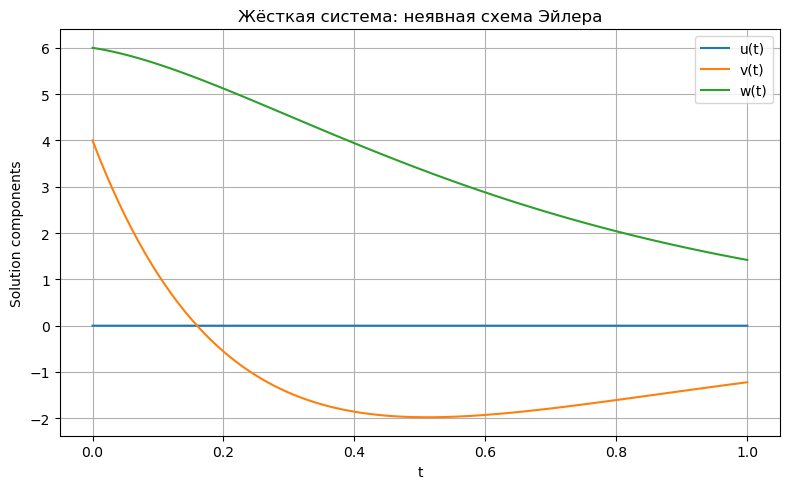

In [13]:
import matplotlib.pyplot as plt

u0 = [0, 4, 6]
T = 1.0
dt = 0.01

tt, y = implicit_euler_system(A, u0, T, dt)

plt.figure(figsize=(8, 5))
plt.plot(tt, y[:, 0], label='u(t)')
plt.plot(tt, y[:, 1], label='v(t)')
plt.plot(tt, y[:, 2], label='w(t)')
plt.xlabel("t")
plt.ylabel("Solution components")
plt.title("Жёсткая система: неявная схема Эйлера")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
def explicit_euler_system(A, u0, T, dt):
    A = np.asarray(A, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.empty((num_steps + 1, len(u0)))
    y[0] = u0
    for k in range(num_steps):
        y[k+1] = y[k] + dt * A @ y[k]
    return tt, y


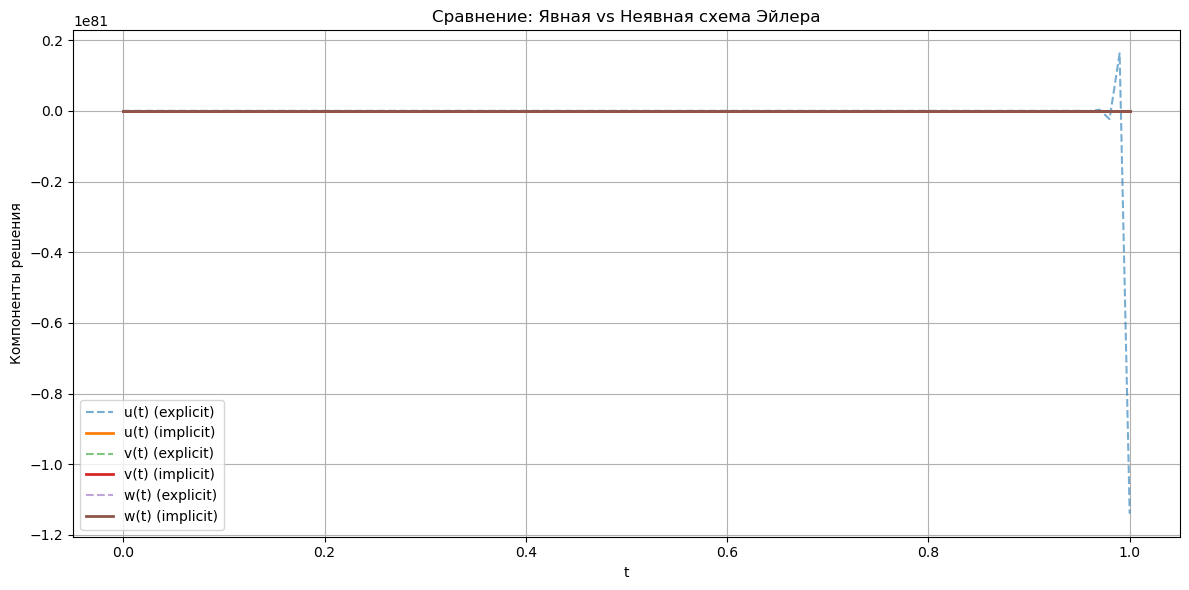

In [15]:
A = np.array([
    [-800, 0.04, 0.02],
    [0,   -5,   -3],
    [0,    1,   -1]
], dtype=float)

u0 = [0, 4, 6]
T = 1.0
dt = 0.01  # попробуй позже и 0.001 для явной схемы

tt_explicit, y_explicit = explicit_euler_system(A, u0, T, dt)
tt_implicit, y_implicit = implicit_euler_system(A, u0, T, dt)

import matplotlib.pyplot as plt

labels = ['u(t)', 'v(t)', 'w(t)']
colors = ['b', 'orange', 'green']

plt.figure(figsize=(12, 6))
for i in range(3):
    plt.plot(tt_explicit, y_explicit[:, i], '--', label=f'{labels[i]} (explicit)', alpha=0.6)
    plt.plot(tt_implicit, y_implicit[:, i], '-', label=f'{labels[i]} (implicit)', linewidth=2)

plt.title("Сравнение: Явная vs Неявная схема Эйлера")
plt.xlabel("t")
plt.ylabel("Компоненты решения")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
#6

In [17]:
def euler_oscillator(omega, u0, v0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    u = np.empty(num_steps + 1)
    v = np.empty(num_steps + 1)
    u[0] = u0
    v[0] = v0
    for k in range(num_steps):
        u[k+1] = u[k] + dt * v[k]
        v[k+1] = v[k] - dt * omega**2 * u[k]
    return tt, u, v


In [18]:
def plot_oscillator(tt, u, v, omega, dt):
    energy = 0.5 * v**2 + 0.5 * (omega**2) * u**2

    plt.figure(figsize=(12, 5))

    # График решений
    plt.subplot(1, 2, 1)
    plt.plot(tt, u, label='u(t)')
    plt.plot(tt, v, label='v(t)')
    plt.title(f'Колебания (dt={dt})')
    plt.xlabel("t")
    plt.ylabel("u, v")
    plt.legend()
    plt.grid(True)

    # Энергия
    plt.subplot(1, 2, 2)
    plt.plot(tt, energy, 'r-', label='E(t)')
    plt.title('Энергия системы')
    plt.xlabel("t")
    plt.ylabel("E")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


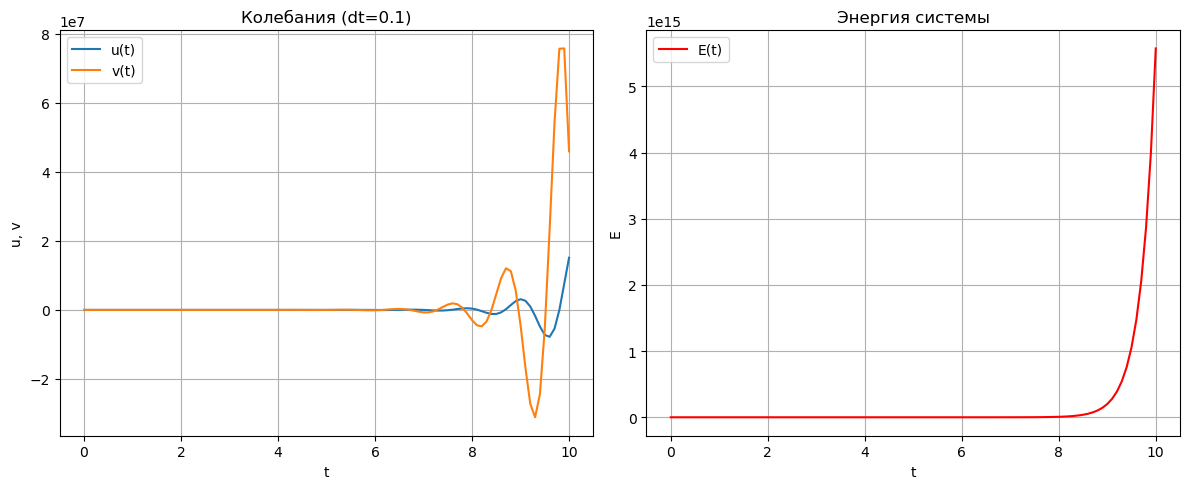

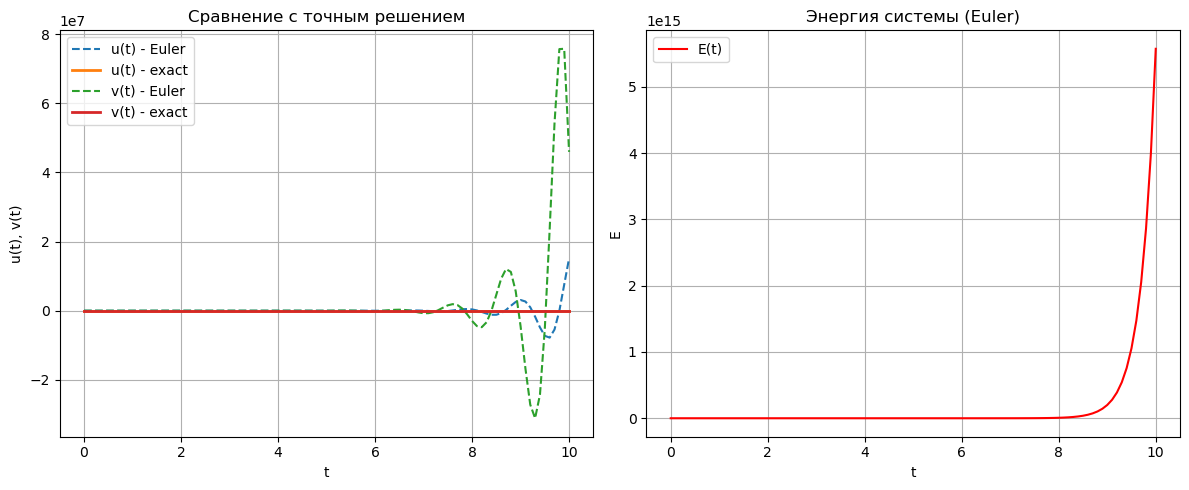

In [19]:
omega = 2 * np.pi  # 1 Гц осцилляция
u0, v0 = 1.0, 0.0  # начальная амплитуда, скорость = 0
T = 10  # 10 секунд (≈10 периодов)
dt = 0.1  # шаг интегрирования

tt, u, v = euler_oscillator(omega, u0, v0, T, dt)
plot_oscillator(tt, u, v, omega, dt)

# Сравнение с точным решением
u_exact = np.cos(omega * tt)
v_exact = -omega * np.sin(omega * tt)

plt.figure(figsize=(12, 5))

# Графики решений и точных функций
plt.subplot(1, 2, 1)
plt.plot(tt, u, label='u(t) - Euler', linestyle='--')
plt.plot(tt, u_exact, label='u(t) - exact', linewidth=2)
plt.plot(tt, v, label='v(t) - Euler', linestyle='--')
plt.plot(tt, v_exact, label='v(t) - exact', linewidth=2)
plt.title('Сравнение с точным решением')
plt.xlabel("t")
plt.ylabel("u(t), v(t)")
plt.legend()
plt.grid(True)

# График энергии
energy = 0.5 * v**2 + 0.5 * omega**2 * u**2
plt.subplot(1, 2, 2)
plt.plot(tt, energy, 'r-', label='E(t)')
plt.title('Энергия системы (Euler)')
plt.xlabel("t")
plt.ylabel("E")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [20]:
def predictor_corrector_energy(omega, u0, v0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    u = np.empty(num_steps + 1)
    v = np.empty(num_steps + 1)

    u[0] = u0
    v[0] = v0
    E0 = 0.5 * v0**2 + 0.5 * omega**2 * u0**2

    for k in range(num_steps):
        # Предиктор (по Эйлеру)
        u_star = u[k] + dt * v[k]
        v_star = v[k] - dt * omega**2 * u[k]

        # Корректор: сохраняем энергию
        arg = 2 * E0 - omega**2 * u_star**2
        if arg < 0:
            arg = 0  # защита от комплексных чисел
        v_new = np.sign(v_star) * np.sqrt(arg)

        u[k+1] = u_star
        v[k+1] = v_new

    return tt, u, v


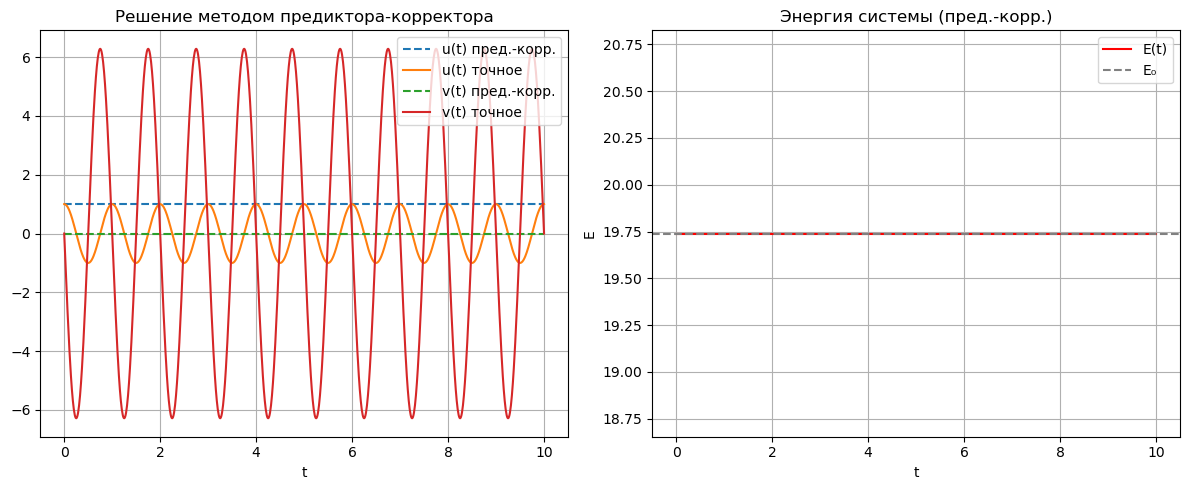

In [21]:
# Параметры задачи
omega = 2 * np.pi  # 1 Гц
u0, v0 = 1.0, 0.0
T = 10             # 10 секунд (≈10 периодов)
dt = 0.01           # шаг интегрирования

# Решение методом предиктор-корректор
tt, u_pc, v_pc = predictor_corrector_energy(omega, u0, v0, T, dt)

# Точное решение
u_exact = np.cos(omega * tt)
v_exact = -omega * np.sin(omega * tt)
energy_pc = 0.5 * v_pc**2 + 0.5 * omega**2 * u_pc**2

# Визуализация
plt.figure(figsize=(12, 5))

# Решения u(t), v(t)
plt.subplot(1, 2, 1)
plt.plot(tt, u_pc, '--', label='u(t) пред.-корр.')
plt.plot(tt, u_exact, '-', label='u(t) точное')
plt.plot(tt, v_pc, '--', label='v(t) пред.-корр.')
plt.plot(tt, v_exact, '-', label='v(t) точное')
plt.title('Решение методом предиктора-корректора')
plt.xlabel("t")
plt.legend()
plt.grid(True)

# Энергия
plt.subplot(1, 2, 2)
plt.plot(tt, energy_pc, 'r-', label='E(t)')
plt.axhline(0.5 * v0**2 + 0.5 * omega**2 * u0**2, color='gray', linestyle='--', label='E₀')
plt.title('Энергия системы (пред.-корр.)')
plt.xlabel("t")
plt.ylabel("E")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [22]:
#7

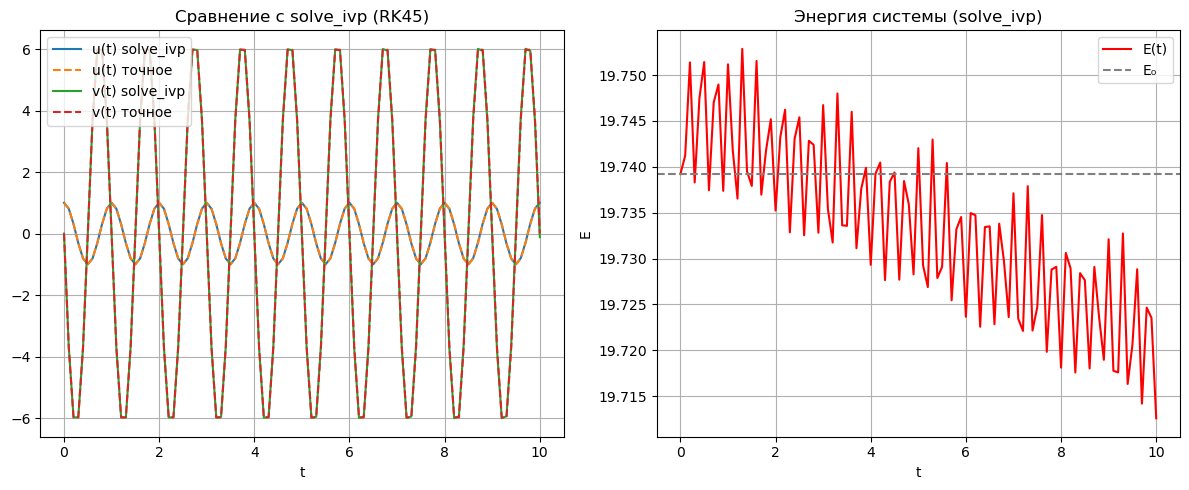

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Уравнение в виде системы
def harmonic(t, y, omega):
    u, v = y
    return [v, -omega**2 * u]

# Параметры
omega = 2 * np.pi
u0, v0 = 1.0, 0.0
T = 10
dt = 0.1
tt = np.arange(0, T + dt, dt)

# Решение через solve_ivp
sol = solve_ivp(harmonic, [0, T], [u0, v0], args=(omega,), t_eval=tt, method='RK45')

u_scipy, v_scipy = sol.y
energy_scipy = 0.5 * v_scipy**2 + 0.5 * omega**2 * u_scipy**2

# Точное решение
u_exact = np.cos(omega * tt)
v_exact = -omega * np.sin(omega * tt)

# Визуализация
plt.figure(figsize=(12, 5))

# Сравнение решений
plt.subplot(1, 2, 1)
plt.plot(tt, u_scipy, label='u(t) solve_ivp')
plt.plot(tt, u_exact, '--', label='u(t) точное')
plt.plot(tt, v_scipy, label='v(t) solve_ivp')
plt.plot(tt, v_exact, '--', label='v(t) точное')
plt.title('Сравнение с solve_ivp (RK45)')
plt.xlabel("t")
plt.legend()
plt.grid(True)

# Энергия
plt.subplot(1, 2, 2)
plt.plot(tt, energy_scipy, 'r-', label='E(t)')
plt.axhline(0.5 * v0**2 + 0.5 * omega**2 * u0**2, color='gray', linestyle='--', label='E₀')
plt.title('Энергия системы (solve_ivp)')
plt.xlabel("t")
plt.ylabel("E")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [24]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y, omega):
    u, v = y
    return np.array([v, -omega**2 * u])

def adams_pc(omega, u0, v0, T, dt):
    steps = int(T / dt)
    t = np.arange(steps + 1) * dt
    y = np.zeros((steps + 1, 2))

    # Старт методом РК4
    y[0] = [u0, v0]
    y[1] = rk4_step(f, 0, y[0], dt, omega)

    for n in range(1, steps):
        fn   = f(t[n], y[n], omega)
        fn_1 = f(t[n-1], y[n-1], omega)

        # Предиктор (Адамс-Бэшфорт 2)
        y_star = y[n] + dt/2 * (3*fn - fn_1)

        # Корректор (Адамс-Мултон 2)
        f_star = f(t[n+1], y_star, omega)
        y[n+1] = y[n] + dt/2 * (f_star + fn)

    return t, y[:, 0], y[:, 1]

def milne_pc(omega, u0, v0, T, dt):
    steps = int(T / dt)
    t = np.arange(steps + 1) * dt
    y = np.zeros((steps + 1, 2))

    # Старт: RK4 на 3 шага
    y[0] = [u0, v0]
    for i in range(3):
        y[i+1] = rk4_step(f, t[i], y[i], dt, omega)

    for n in range(3, steps):
        f_n   = f(t[n], y[n], omega)
        f_n1  = f(t[n-1], y[n-1], omega)
        f_n2  = f(t[n-2], y[n-2], omega)
        f_n3  = f(t[n-3], y[n-3], omega)

        # Предиктор (Милн)
        y_star = y[n-3] + (4*dt/3)*(2*f_n - f_n1 + 2*f_n2)

        # Корректор
        f_star = f(t[n+1], y_star, omega)
        y[n+1] = y[n-1] + (dt/3)*(f_n1 + 4*f_n + f_star)

    return t, y[:, 0], y[:, 1]

def rk4_step(f, t, y, h, omega):
    k1 = f(t, y, omega)
    k2 = f(t + h/2, y + h/2 * k1, omega)
    k3 = f(t + h/2, y + h/2 * k2, omega)
    k4 = f(t + h, y + h * k3, omega)
    return y + h/6 * (k1 + 2*k2 + 2*k3 + k4)


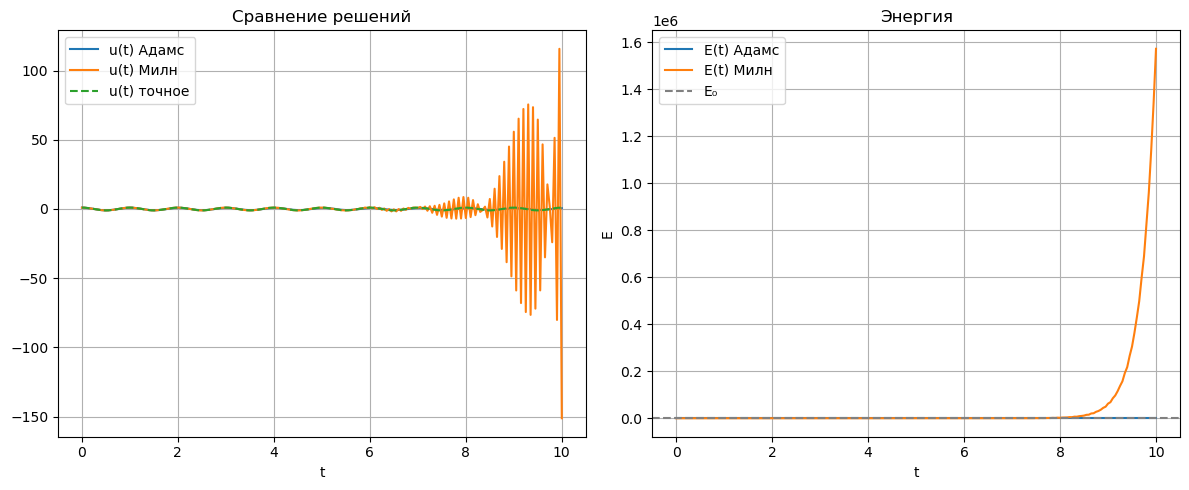

In [25]:
omega = 2*np.pi
u0, v0 = 1.0, 0.0
T = 10
dt = 0.05

# Решения
t_adams, u_adams, v_adams = adams_pc(omega, u0, v0, T, dt)
t_milne, u_milne, v_milne = milne_pc(omega, u0, v0, T, dt)

# Энергия
E_adams = 0.5 * v_adams**2 + 0.5 * omega**2 * u_adams**2
E_milne = 0.5 * v_milne**2 + 0.5 * omega**2 * u_milne**2
E_exact = 0.5 * omega**2 * u0**2 + 0.5 * v0**2

# Визуализация
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(t_adams, u_adams, label='u(t) Адамс')
plt.plot(t_milne, u_milne, label='u(t) Милн')
plt.plot(t_adams, np.cos(omega * t_adams), '--', label='u(t) точное')
plt.title('Сравнение решений')
plt.xlabel("t")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t_adams, E_adams, label='E(t) Адамс')
plt.plot(t_milne, E_milne, label='E(t) Милн')
plt.axhline(E_exact, linestyle='--', color='gray', label='E₀')
plt.title('Энергия')
plt.xlabel("t")
plt.ylabel("E")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [26]:
#8


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Правая часть уравнения
def n_func(x):
    return 1 + np.exp(-3 * (x - 5)**2)

def rhs(x, y):
    phi, dphi = y
    return [dphi, np.exp(phi) - n_func(x)]

# Начальные условия
phi0 = 0
dphi0 = 0
x_span = (0, 10)
x_eval = np.linspace(0, 10, 500)

# Численное решение
sol = solve_ivp(rhs, x_span, [phi0, dphi0], t_eval=x_eval, method='RK45')

x = sol.t
phi = sol.y[0]  # ← только компоненту φ(x)


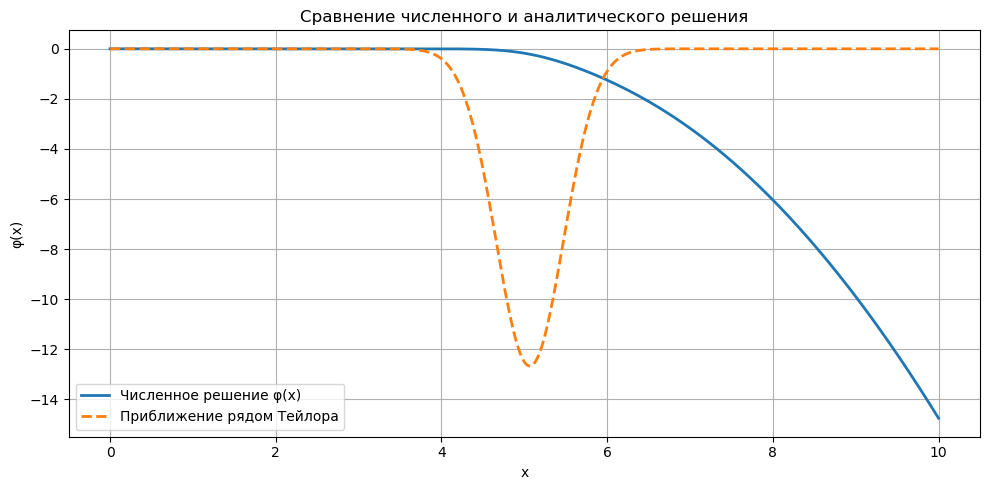

In [28]:
def n_func(x):
    return 1 + np.exp(-3 * (x - 5)**2)

# Аппроксимация Тейлора второго порядка
phi_approx = 0.5 * (1 - n_func(x)) * x**2

# Построим сравнение
plt.figure(figsize=(10, 5))
plt.plot(x, phi, label='Численное решение φ(x)', linewidth=2)
plt.plot(x, phi_approx, '--', label='Приближение рядом Тейлора', linewidth=2)
plt.xlabel("x")
plt.ylabel("φ(x)")
plt.title("Сравнение численного и аналитического решения")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [29]:
#10


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp
import ipywidgets as widgets
from IPython.display import display, clear_output

# Уравнение
def system(t, Y, omega, beta):
    y, v = Y
    return [v, -omega**2 * y - beta * y**3]

# Интерфейс: 2 колонки
style = {'description_width': 'initial'}
left = widgets.VBox([
    widgets.FloatText(value=1.0, description='ω (частота):', style=style),
    widgets.FloatText(value=1.0, description='β (нелинейность):', style=style),
    widgets.FloatText(value=1.0, description='q = y(0):', style=style),
    widgets.FloatText(value=0.0, description="r = y'(0):", style=style),
])

right = widgets.VBox([
    widgets.IntText(value=1000, description='Число шагов:', style=style),
    widgets.FloatText(value=20.0, description='Время интегрирования:', style=style),
    widgets.Text(value='данные.csv', description='Имя файла для сохранения:', style=style),
    widgets.Button(description='Старт моделирования', button_style='success')
])

ui = widgets.HBox([left, right])
display(ui)

# Привязка элементов
omega_input     = left.children[0]
beta_input      = left.children[1]
q_input         = left.children[2]
r_input         = left.children[3]

steps_input     = right.children[0]
tmax_input      = right.children[1]
filename_input  = right.children[2]
run_button      = right.children[3]

# Графики + анимация
output = widgets.Output()
display(output)

def on_run_button_clicked(_):
    output.clear_output()
    with output:
        print("Кнопка нажата")

        try:
            # Считываем параметры
            omega = omega_input.value
            beta  = beta_input.value
            q     = q_input.value
            r     = r_input.value
            steps = steps_input.value
            t_max = tmax_input.value

            print(f"Параметры: ω={omega}, β={beta}, q={q}, r={r}, steps={steps}, t_max={t_max}")

            # Интегрирование
            t_eval = np.linspace(0, t_max, steps)
            sol = solve_ivp(system, [0, t_max], [q, r], args=(omega, beta), t_eval=t_eval)

            print("Решение получено")

            t = sol.t
            y = sol.y[0]
            v = sol.y[1]

            # Сохраняем результат
            np.savetxt(filename_input.value, np.vstack([t, y, v]).T, delimiter=',', header='t,y,v', comments='')
            print(f"Данные сохранены в файл: {filename_input.value}")

            # Построение графиков
            fig, axs = plt.subplots(1, 2, figsize=(12, 5))
            axs[0].plot(t, y, label='y(t)')
            axs[0].plot(t, v, label="y'(t)")
            axs[0].set_title('Временные зависимости')
            axs[0].legend()
            axs[0].grid()

            axs[1].plot(y, v)
            axs[1].set_title('Фазовый портрет')
            axs[1].set_xlabel('y')
            axs[1].set_ylabel("y'")
            axs[1].grid()
            plt.tight_layout()
            plt.show()

            print("Графики построены")

            # Анимация
            fig2, ax2 = plt.subplots(figsize=(5,5))
            ax2.set_xlim(min(y)*1.1, max(y)*1.1)
            ax2.set_ylim(min(v)*1.1, max(v)*1.1)
            ax2.set_xlabel('y')
            ax2.set_ylabel("y'")
            ax2.set_title('Анимация фазового портрета')
            ax2.grid()
            point, = ax2.plot([], [], 'ro')
            trail, = ax2.plot([], [], 'b-', alpha=0.5)

            def init():
                point.set_data([], [])
                trail.set_data([], [])
                return point, trail

            def update(i):
                point.set_data(y[i], v[i])
                trail.set_data(y[:i+1], v[:i+1])
                return point, trail

            anim = FuncAnimation(fig2, update, frames=len(t), init_func=init,
                                 interval=20, blit=True)
            # plt.show()

        except Exception as e:
            print("Ошибка во время выполнения:")
            print(e)

run_button.on_click(on_run_button_clicked)


Output()